# Stage 3: Sample Uniqueness and Weights
This notebook implements concurrent-label counting, uniqueness, sequential bootstrap, and time decay weights.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append('../')
from src.sample_weights import num_co_events, sample_tw, get_ind_matrix, seq_bootstrap, get_return_attribution, get_time_decay, get_sample_weight

plt.style.use('seaborn-v0_8-darkgrid')


## 1. Load Data


In [2]:
close_df = pd.read_parquet('../data/processed/nvda_clean.parquet')
close = close_df['Adj Close']

labels = pd.read_parquet('../data/processed/nvda_labels.parquet')
labels.head()


,t1,pt,sl,ret,bin
2005-01-27,2005-02-07,2005-02-02,NaT,0.075949,1.0
2005-02-18,2005-02-28,NaT,NaT,0.025469,1.0
2005-03-08,2005-03-18,NaT,2005-03-11,-0.048408,-1.0
2005-05-13,2005-05-23,2005-05-20,NaT,0.038298,1.0
2005-06-14,2005-06-24,2005-06-23,NaT,0.039764,1.0


## 2. Concurrency Count


In [3]:
co_events = num_co_events(close.index, labels['t1'], labels.index)
print("Concurrency counts computed.")


Concurrency counts computed.


## 3. Average Uniqueness


In [4]:
avg_uniqueness = sample_tw(labels['t1'], co_events, labels.index)
avg_uniqueness.describe()


count    399.000000
mean       0.616280
std        0.273615
min        0.144558
25%        0.377315
50%        0.562500
75%        0.888889
max        1.000000
dtype: float64

## 4. Sequential vs Standard Bootstrap


In [5]:
ind_matrix = get_ind_matrix(close.index, labels['t1'])

# Standard bootstrap (100 draws)
np.random.seed(42)
std_bootstrap = np.random.choice(range(ind_matrix.shape[1]), size=100, replace=True)

# Sequential bootstrap (100 draws)
seq_boot = seq_bootstrap(ind_matrix, s_length=100)

# Evaluate average uniqueness of drawn samples
std_u = avg_uniqueness.iloc[std_bootstrap].mean()
seq_u = avg_uniqueness.iloc[seq_boot].mean()

print(f"Standard Bootstrap Average Uniqueness: {std_u:.4f}")
print(f"Sequential Bootstrap Average Uniqueness: {seq_u:.4f}")


Standard Bootstrap Average Uniqueness: 0.6153
Sequential Bootstrap Average Uniqueness: 0.6126


## 5. Return-Attribution Weights


In [6]:
ret_weights = get_return_attribution(labels)
ret_weights.describe()


count    399.000000
mean       1.002506
std        0.513837
min        0.004640
25%        0.676167
50%        0.922038
75%        1.234915
max        3.717770
Name: ret, dtype: float64

## 6. Time Decay


In [7]:
decay_weights = get_time_decay(avg_uniqueness, c_lf=0.5)
decay_weights.describe()


count    400.000000
mean       1.000000
std        0.193173
min        0.666667
25%        0.833333
50%        1.000000
75%        1.166667
max        1.333333
dtype: float64

## 7. Final Combined Weights


In [8]:
final_weights = get_sample_weight(labels, close)
labels['weight'] = final_weights
print("Final Weights Statistics:")
display(labels['weight'].describe())


Final Weights Statistics:


count    399.000000
mean       1.000000
std        0.498191
min        0.006225
25%        0.644200
50%        0.927319
75%        1.278631
max        3.008112
Name: weight, dtype: float64

## 8. Plots


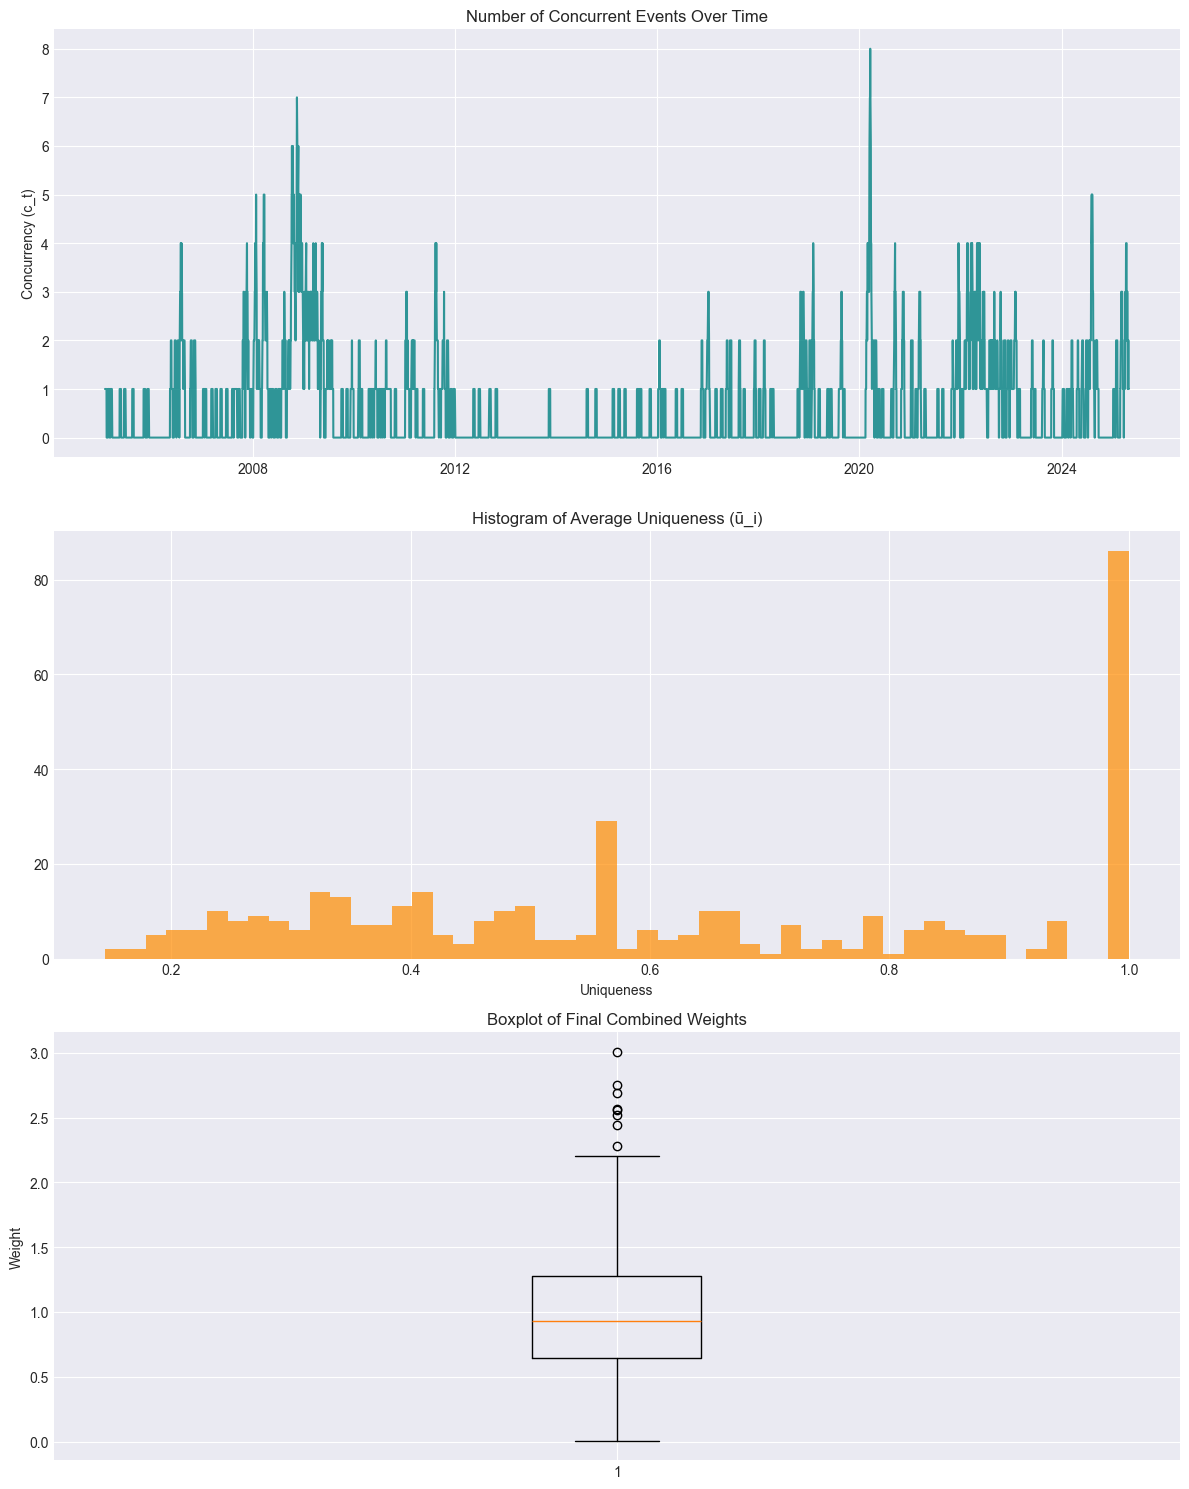

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(12, 15))

# a. Concurrency over time
axes[0].plot(co_events.index, co_events.values, color='teal', alpha=0.8)
axes[0].set_title('Number of Concurrent Events Over Time')
axes[0].set_ylabel('Concurrency (c_t)')

# b. Uniqueness histogram
axes[1].hist(avg_uniqueness, bins=50, color='darkorange', alpha=0.7)
axes[1].set_title('Histogram of Average Uniqueness (ū_i)')
axes[1].set_xlabel('Uniqueness')

# c. Weight distribution boxplot
axes[2].boxplot(final_weights.dropna())
axes[2].set_title('Boxplot of Final Combined Weights')
axes[2].set_ylabel('Weight')

plt.tight_layout()
plt.show()


## 9. Save Sample Weights


In [10]:
labels[['weight']].to_parquet('../data/processed/nvda_sample_weights.parquet')
print("Saved nvda_sample_weights.parquet")


Saved nvda_sample_weights.parquet
